# Import Libraries

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Write a Python function for $f(\theta)$
Write a Matlab function file for $f(\theta)$. The parameters $L_1, L_2, L_3, \gamma, x_1, x_2, y_2$ are fixed constants, and the strut lengths $p_1, p_2, p_3$ will be known for a given pose. To test your code, set the parameters $L_1 = 2$, $L_2 = L_3 = \sqrt{2}$, $\gamma = \pi/2$, and $p_1 = p_2 = p_3 = \sqrt{5}$. Then, substituting $\theta = -\pi/4$ or $\theta = \pi/4$, should make $f(\theta) = 0$.

## Create function for $f(\theta)$

In [134]:
import numpy as np
import matplotlib.pyplot as plt
class StewartPlatform:
    """
    Class to store the parameters for the Stewart platform and perform calculations.
    The parameters can be updated for reuse.
    """
    def __init__(self, theta=None, l1=None, l2=None, l3=None, x0=None, x1=None, x2=None, y0=None, y1=None, y2=None, gama=None, p1=None, p2=None, p3=None, theta_values=None):
        # Initialize with default None to allow setting them later
        self.theta = theta  # Angle in radians
        self.negative_theta = -theta if theta is not None else None  # Store the negative of theta
        print(f'Negative theta: {self.negative_theta}')
        print(f'Positive theta: {self.theta}')
        self.l1 = l1        # Length of one side of the triangle
        self.l2 = l2        # Length of another side of the triangle
        self.l3 = l3        # Length of the third side of the triangle
        self.x0 = x0        # X-coordinate of the first triangle vertex
        self.x1 = x1        # X-coordinate of the second triangle vertex
        self.x2 = x2        # X-coordinate of the third triangle vertex
        self.y0 = y0        # Y-coordinate of the first triangle vertex
        self.y1 = y1        # Y-coordinate of the second triangle vertex
        self.y2 = y2        # Y-coordinate of the third triangle vertex
        self.gama = gama    # Angle between struts (if applicable)
        self.p1 = p1        # Length of the first strut
        self.p2 = p2        # Length of the second strut
        self.p3 = p3        # Length of the third strut

        # Print all parameters
        print(f'l1: {self.l1}')
        print(f'l2: {self.l2}')
        print(f'l3: {self.l3}')
        print(f'x0: {self.x0}')
        print(f'x1: {self.x1}')
        print(f'x2: {self.x2}')
        print(f'y0: {self.y0}')
        print(f'y1: {self.y1}')
        print(f'y2: {self.y2}')
        print(f'gama: {self.gama}')
        print(f'p1: {self.p1}')
        print(f'p2: {self.p2}')
        print(f'p3: {self.p3}')

        
        # Set theta_values, defaulting to np.linspace(-np.pi, np.pi, 1000) if not provided
        self.theta_values = theta_values if theta_values is not None else np.linspace(-np.pi, np.pi, 1000)

        # Calculate x and y when the class is initialized
        self.root, self.x, self.y = self.calculate()
        
        # Get triangle points for positive and negative theta
        self.triangle_points_pos_theta = self.get_triangle_points(self.theta)
        self.triangle_points_neg_theta = self.get_triangle_points(self.negative_theta)
        
        # Extract l1_point, l2_point, l3_point for positive theta
        self.l1_point_pos, self.l2_point_pos, self.l3_point_pos = self.triangle_points_pos_theta
        
        # Extract l1_point, l2_point, l3_point for negative theta
        self.l1_point_neg, self.l2_point_neg, self.l3_point_neg = self.triangle_points_neg_theta

        # Get anchor points
        self.anchor_points = self.get_anchor_points(self.x1, self.x2, self.y2)
        print(f'Anchor Points: {self.anchor_points}')
    
    def calculate(self):
        """
        Calculates the x and y coordinates based on the triangle side lengths and strut lengths.
        Returns:
        float: The calculated result.
        float: The x-coordinate result.
        float: The y-coordinate result.

        Raises:
        ZeroDivisionError: If the denominator d is zero.
        """
        if any(param is None for param in [self.theta, self.l1, self.l2, self.l3, self.x0, self.x1, self.x2, self.y0, self.y1, self.y2, self.p1, self.p2, self.p3]):
            raise ValueError("All parameters must be set before calculation.")
        
        # Calculate intermediate values a2, b2, a3, b3
        a2 = (self.l3 * np.cos(self.theta)) - self.x1
        b2 = (self.l3 * np.sin(self.theta)) - self.y1
        
        a3 = (self.l2 * np.cos(self.theta + self.gama)) - self.x2
        b3 = (self.l2 * np.sin(self.theta + self.gama)) - self.y2

        # Calculate n1, n2, and d
        n1 = (b3 * ((self.p2 ** 2) - (self.p1 ** 2) - (a2 ** 2) - (b2 ** 2))) - (b2 * ((self.p3 ** 2) - (self.p1 ** 2) - (a3 ** 2) - (b3 ** 2)))
        n2 = (-a3 * ((self.p2 ** 2) - (self.p1 ** 2) - (a2 ** 2) - (b2 ** 2))) + (a2 * ((self.p3 ** 2) - (self.p1 ** 2) - (a3 ** 2) - (b3 ** 2)))
        
        d = 2 * ((a2 * b3) - (b2 * a3))
        
        # Check for division by zero
        if d == 0:
            raise ZeroDivisionError("d cannot be zero, division by zero error.")
        
        x = n1 / d
        y = n2 / d

        # Continue with calculations involving d (if applicable)
        root = (n1 ** 2) + (n2 ** 2) - ((self.p1 ** 2) * (d ** 2))
        
        return root, x, y

    def get_triangle_points(self, theta):
        """
        Calculate the points of the triangle based on x, y, and angles.
        """
        print(f'Tri theta : {theta}')
        
        l1_point = (self.x, self.y)
        
        l2_x = self.x + (self.l3 * np.cos(theta))
        l2_y = self.y + (self.l3 * np.sin(theta))
        l2_point = (np.round(l2_x), np.round(l2_y))
        
        l3_x = self.x + (self.l2 * np.cos(theta + self.gama))
        l3_y = self.y + (self.l2 * np.sin(theta + self.gama))
        l3_point = (np.round(l3_x), np.round(l3_y))
        
        
        return [l1_point, l2_point, l3_point]
    
    
   
    def get_anchor_points(self, x1, x2, y2):
        """
        Generate the anchor points based on input coordinates.
        """
        return [(0, 0), (x1, 0), (x2, y2)]
    
    def plot_f_theta(self):
        """
        Plots the function f(theta) over the range of theta values defined in the instance.
        """
        results = []
        for theta in self.theta_values:
            # Update theta and dependent attributes
            self.theta = theta
            self.negative_theta = -theta
            try:
                # Recalculate x, y, and root
                self.root, self.x, self.y = self.calculate()
                results.append(self.root)
            except ZeroDivisionError:
                results.append(np.nan)
        
        # Plot the results
        plt.figure(figsize=(10, 6))
        plt.plot(self.theta_values, results, label=r'$f(\theta)$')  # Default linewidth
        plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Default linewidth
        plt.axvline(-np.pi/4, color='red', linestyle=':', linewidth=2, label=r'$\theta = -\pi/4$')  # Increased linewidth
        plt.axvline(np.pi/4, color='red', linestyle=':', linewidth=2, label=r'$\theta = \pi/4$')  # Increased linewidth
        plt.xlabel(r'$\theta$', fontsize=14)
        plt.ylabel(r'$f(\theta)$', fontsize=14)
        plt.title(r'Function of $f(\theta)$ for Stewart Platform', fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True)
        plt.show()

    def plot_triangle(self, ax, points, anchor_points):
        """
        Plot the triangle on a given axis.
        """
        points = np.array(points)
        anchor_points = np.array(anchor_points)
        
        # Extract the x and y coordinates for the triangle vertices
        x_coords = points[:, 0]
        y_coords = points[:, 1]
        
        # Close the triangle by repeating the first point at the end
        x_closed = np.append(x_coords, x_coords[0])
        y_closed = np.append(y_coords, y_coords[0])
        
        # Plot the triangle with thicker lines
        ax.plot(x_closed, y_closed, 'r-', linewidth=3.5)
        
        # Plot red dots at the triangle vertices
        ax.plot(x_coords, y_coords, 'bo', markersize=8)
        
        # Plot lines from base points to corresponding triangle vertices
        for i, anchor in enumerate(anchor_points):
            ax.plot([anchor[0], points[i, 0]], [anchor[1], points[i, 1]], 'b-', linewidth=1.5)
        
        # Plot small blue circles at the strut anchor points
        ax.plot(anchor_points[:, 0], anchor_points[:, 1], 'bo', markersize=8)
        
        # Set labels and title
        ax.set_title("Triangle with Given Vertices and Strut Anchors")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        
        # Set the domain and range for both axes
        ax.set_xlim(-0.25, 4.25)
        ax.set_ylim(-0.25, 4.25)
        
        # Add grid for better visualization
        ax.grid(True)

    def plot_side_by_side(self):
        """
        Create side-by-side plots for both positive and negative theta values.
        """
        # Recalculate triangle points with updated theta values
        self.triangle_points_neg_theta = self.get_triangle_points(self.x, self.y, self.negative_theta, self.gama)
        self.triangle_points_pos_theta = self.get_triangle_points(self.x, self.y, self.theta, self.gama)
        
        # Print anchor and triangle points
        print(f'Anchor points: {self.anchor_points}')
        print(f'Negative theta points: {self.triangle_points_neg_theta}')
        print(f'Positive theta points: {self.triangle_points_pos_theta}')
        
        # Create subplots for side-by-side triangles
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Plot the first triangle on the first axis (negative theta)
        self.plot_triangle(axes[0], self.triangle_points_neg_theta, self.anchor_points)
        
        # Plot the second triangle on the second axis (positive theta)
        self.plot_triangle(axes[1], self.triangle_points_pos_theta, self.anchor_points)
        
        # Adjust layout to avoid overlap
        plt.tight_layout()

        # Display the concatenated plots
        plt.show()


## Test function $f(\theta)$

In [135]:
# Instantiate your StewartPlatform object
stewart_platform = StewartPlatform(
    theta= np.pi / 4,
    l1=2,
    l2=np.sqrt(2),
    l3=np.sqrt(2),
    x0=0,
    y0=0,
    x1=4,
    y1=0,
    x2=0,
    y2=4,
    gama=np.pi / 2,
    p1=np.sqrt(5),
    p2=np.sqrt(5),
    p3=np.sqrt(5)
)


# Calculate and print results
result, x, y = stewart_platform.calculate()
print("Result:", result)
print("X:", x)
print("Y:", y) 

# Print the triangle points for positive and negative theta
print("\nTriangle points for positive theta:")
print("l1_point:", stewart_platform.l1_point_pos)
print("l2_point:", stewart_platform.l2_point_pos)
print("l3_point:", stewart_platform.l3_point_pos)

print("\nTriangle points for negative theta:")
print("l1_point:", stewart_platform.l1_point_neg)
print("l2_point:", stewart_platform.l2_point_neg)
print("l3_point:", stewart_platform.l3_point_neg)

Negative theta: -0.7853981633974483
Positive theta: 0.7853981633974483
l1: 2
l2: 1.4142135623730951
l3: 1.4142135623730951
x0: 0
x1: 4
x2: 0
y0: 0
y1: 0
y2: 4
gama: 1.5707963267948966
p1: 2.23606797749979
p2: 2.23606797749979
p3: 2.23606797749979
Tri theta : 0.7853981633974483


NameError: name 'L2' is not defined

# 2. Plot $f(\theta)$ on $[-π, π]$

## Create Plot

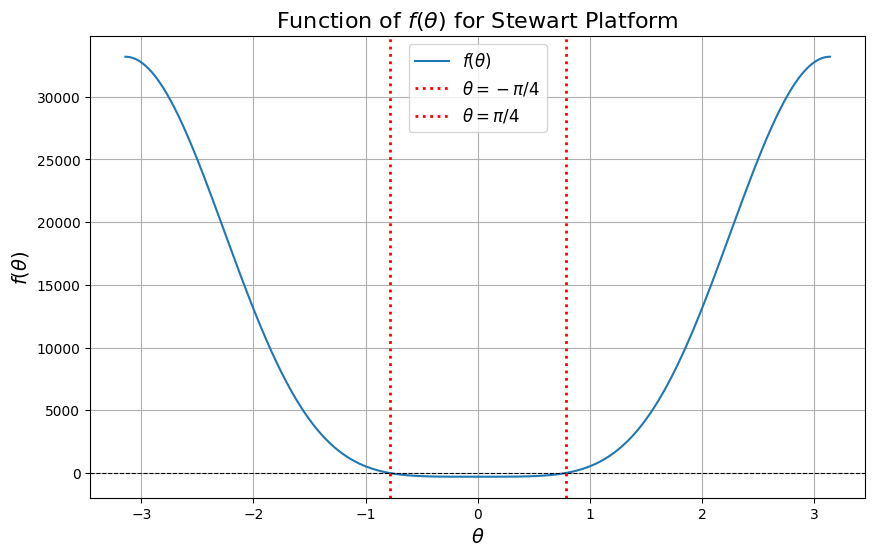

In [124]:
# Plot f(theta) over the range defined in the class
stewart_platform.plot_f_theta()


# 3. Reproduce Figure 1.15.

Reproduce Figure 1.15. Use the following Matlab commands to plot a red triangle with vertices $(u_1, v_1), (u_2, v_2), (u_3, v_3)$ and place small blue circles at the strut anchor points $(0,0), (x_1, 0), (x_2, y_2)$:

Tri theta : -3.141592653589793
Tri theta : 3.141592653589793
Anchor points: [(0, 0), (4, 0), (0, 4)]
Negative theta points: [(np.float64(2.7071067811865475), np.float64(2.7071067811865475)), (np.float64(1.0), np.float64(3.0)), (np.float64(3.0), np.float64(1.0))]
Positive theta points: [(np.float64(2.7071067811865475), np.float64(2.7071067811865475)), (np.float64(1.0), np.float64(3.0)), (np.float64(3.0), np.float64(1.0))]


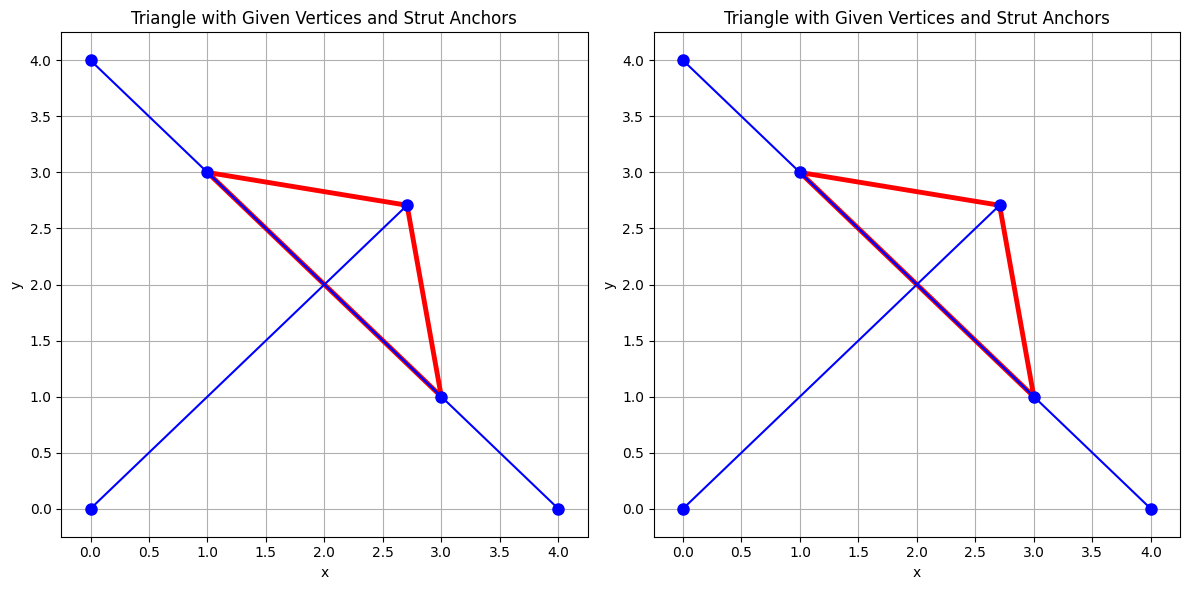

In [125]:
stewart_platform.plot_side_by_side()

In [126]:
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate the points of the triangle based on x, y, and angles
def get_triangle_points(x, y, theta, gama):
    L1_point = (x, y)
    
    L2_x = x + (L3 * np.cos(theta))
    L2_y = y + (L3 * np.sin(theta))
    L2_point = (np.round(L2_x), np.round(L2_y))
    
    L3_x = x + (L2 * np.cos(theta + gama))
    L3_y = y + (L2 * np.sin(theta + gama))
    L3_point = (np.round(L3_x), np.round(L3_y))
    
    return [L1_point, L2_point, L3_point]

# Function to generate the anchor points
def get_anchor_points(x1, x2, y2):
    return [(0, 0), (x1, 0), (x2, y2)]

# Function to plot the triangle on a given axis
def plot_triangle(ax, points, anchor_points):
    # Ensure points and anchor_points are numpy arrays
    points = np.array(points)
    anchor_points = np.array(anchor_points)
    
    # Extract the x and y coordinates for the triangle vertices
    x_coords = points[:, 0]
    y_coords = points[:, 1]
    
    # Close the triangle by repeating the first point at the end
    x_closed = np.append(x_coords, x_coords[0])
    y_closed = np.append(y_coords, y_coords[0])
    
    # Plot the triangle with thicker lines
    ax.plot(x_closed, y_closed, 'r-', linewidth=3.5)
    
    # Plot red dots at the triangle vertices
    ax.plot(x_coords, y_coords, 'bo', markersize=8)
    
    # Plot lines from base points to corresponding triangle vertices
    for i, anchor in enumerate(anchor_points):
        ax.plot([anchor[0], points[i, 0]], [anchor[1], points[i, 1]], 'b-', linewidth=1.5)
    
    # Plot small blue circles at the strut anchor points
    ax.plot(anchor_points[:, 0], anchor_points[:, 1], 'bo', markersize=8)
    
    # Set labels and title
    ax.set_title("Triangle with Given Vertices and Strut Anchors")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    
    # Set the domain and range for both axes
    ax.set_xlim(-0.25, 4.25)
    ax.set_ylim(-0.25, 4.25)
    
    # Add grid for better visualization
    ax.grid(True)


theta = np.pi / 4
theta_negative = -np.pi / 4
gama = np.pi / 2

# First triangle points
_, x, y = f(theta_negative)  # Assuming f is defined elsewhere
points1 = get_points(x, y, theta_negative, gama)
anchor_points = get_anchor_points(4, 0, 4)

# Second triangle points
_, x, y = f(theta)  # Assuming f is defined elsewhere
points2 = get_points(x, y, theta, gama)

# Create subplots for side-by-side triangles
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first triangle on the first axis
plot_triangle(axes[0], points1, anchor_points)

# Plot the second triangle on the second axis
plot_triangle(axes[1], points2, anchor_points)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the concatenated plots
plt.show()


NameError: name 'f' is not defined

# 4. Forward Kinematics for a Planar Stewart Platform with Given Strut Lengths and Angles


Solve the forward kinematics problem for the planar Stewart platform specified by 
$z_1 = 5, (x_2, y_2) = (0,6), L_1 = L_3 = 3, L_2 = 3\sqrt{2}, \gamma = \frac{\pi}{4}, p_1 = p_2 = 5, p_3 = 3$. 
Begin by plotting $f(\theta)$. Use an equation solver of your choice to find all four poses (roots of $f(\theta)$), 
and plot them. Check your answers by verifying that $p_1, p_2, p_3$ are the lengths of the struts in your plot.

